In [3]:
import ee
ee.Initialize(project='gen-lang-client-0292822679')

region = ee.Geometry.Rectangle([100, 5, 120, 25])  # Vietnam box

era5 = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY") \
    .filterDate("2024-01-01", "2025-01-01") \
    .select([
        "total_precipitation",
        "temperature_2m",
        "u_component_of_wind_10m",
        "v_component_of_wind_10m"
    ])

monthly_mean = era5.mean().clip(region)

task = ee.batch.Export.image.toDrive(
    image=monthly_mean,
    description="era5_multi_vietnam",
    region=region,
    scale=10000,
    fileFormat="GeoTIFF"
)

task.start()

In [11]:
import rioxarray

ds = rioxarray.open_rasterio("era5_multi_vietnam.tif")
print(ds)

<xarray.DataArray (band: 4, y: 228, x: 223)> Size: 2MB
[203376 values with dtype=float64]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 2kB 25.38 25.29 25.2 25.11 ... 5.165 5.075 4.986
  * x            (x) float64 2kB 100.0 100.1 100.2 100.3 ... 119.8 119.9 120.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('total_precipitation', 'temperature_2m', 'u_component_of...


In [13]:
import numpy as np

precip_mm = ds.sel(band=1) * 1000          # meters → mm
temp_c = ds.sel(band=2) - 273.15           # Kelvin → Celsius

u = ds.sel(band=3)
v = ds.sel(band=4)
wind_speed = np.sqrt(u**2 + v**2)

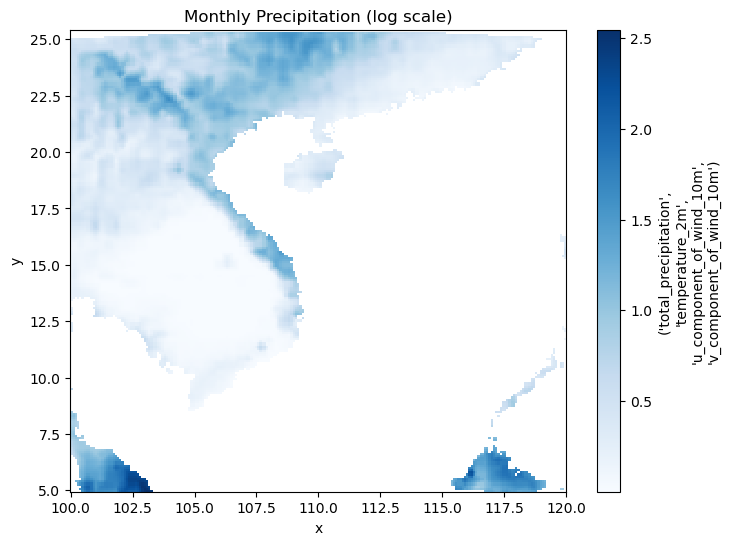

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
np.log1p(precip_mm).plot(cmap="Blues")
plt.title("Monthly Precipitation (log scale)")
plt.show()

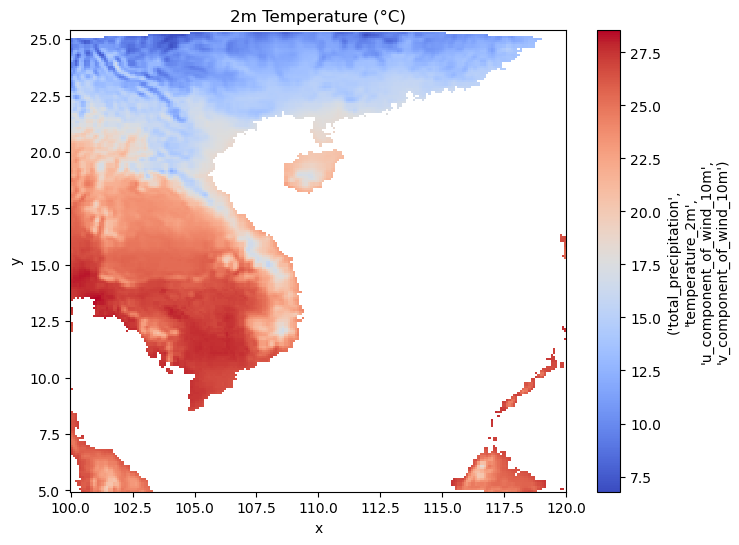

In [15]:
plt.figure(figsize=(8,6))
temp_c.plot(cmap="coolwarm")
plt.title("2m Temperature (°C)")
plt.show()

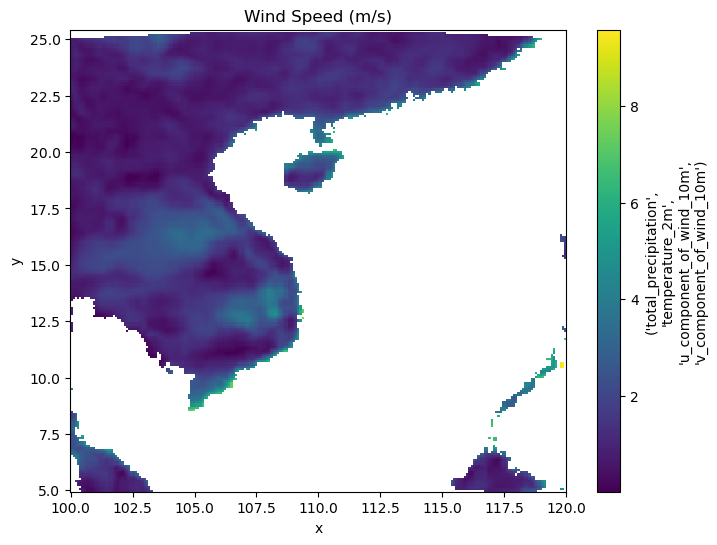

In [16]:
plt.figure(figsize=(8,6))
wind_speed.plot(cmap="viridis")
plt.title("Wind Speed (m/s)")
plt.show()